In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from functools import partial
from scipy.optimize import minimize
import pandas as pd
import random
import matplotlib
from math import gcd

# Цепи Маркова

1. Дана м.в.п. однородной цепи Маркова

Найти стационарное распределение.

Возвести матрицу в степени от 10 до 20 и описать как меняется матрица и как это связано с
эргодической теоремой.

![опа картинка](matprak7_pic.png)

In [2]:
matrix1 = np.array([[1/4, 3/4, 0, 0],
                    [1/2, 0, 1/2, 0],
                    [0, 1/2, 0, 1/2],
                    [0, 0, 3/4, 1/4]])

matrix2 = np.array([[2/9, 1/3, 0, 4/9],
                    [4/9, 1/9, 0, 4/9],
                    [2/9, 2/9, 2/9, 1/3],
                    [2/9, 2/9, 4/9, 1/9]])

matrix3 = np.array([[0, 1/2, 0, 1/2],
                    [1/3, 0, 2/3, 0],
                    [0, 1/4, 0, 3/4],
                    [1/4, 0, 3/4, 0]])

matrix4 = np.array([[1/6,1/6,1/6, 1/2, 0],
                    [0, 1/3, 0, 2/3, 0],
                    [0,0,0,0,1],
                    [0,1,0,0,0],
                    [0,0,1,0,0]])

In [5]:
def find_erg(matrix):
    eigvals, eigvects = np.linalg.eig(np.transpose(matrix))
    index_1 = np.argmin(np.abs(eigvals - 1))
    pi = np.real(eigvects[:,index_1])
    pi = pi/np.sum(pi)
    return pi

def matrix_power(matrix):
    for power in range(10,21):
        print(f"n = {power}")
        print(np.linalg.matrix_power(matrix, power))
        print("")


In [18]:
print(find_erg(matrix1))

matrix_power(matrix1)

[0.2 0.3 0.3 0.2]
n = 10
[[0.22371578 0.25403881 0.34596062 0.17628479]
 [0.16935921 0.36967659 0.23032379 0.23064041]
 [0.23064041 0.23032379 0.36967659 0.16935921]
 [0.17628479 0.34596062 0.25403881 0.22371578]]

n = 11
[[0.18294835 0.34076715 0.259233   0.21705151]
 [0.2271781  0.2421813  0.3578186  0.172822  ]
 [0.172822   0.3578186  0.2421813  0.2271781 ]
 [0.21705151 0.259233   0.34076715 0.18294835]]

n = 12
[[0.21612066 0.26682776 0.3331722  0.18387938]
 [0.17788517 0.34929287 0.25070715 0.2221148 ]
 [0.2221148  0.25070715 0.34929287 0.17788517]
 [0.18387938 0.3331722  0.26682776 0.21612066]]

n = 13
[[0.18744405 0.3286766  0.27132341 0.21255594]
 [0.21911773 0.25876746 0.34123254 0.18088228]
 [0.18088228 0.34123254 0.25876746 0.21911773]
 [0.21255594 0.27132341 0.3286766  0.18744405]]

n = 14
[[0.21119931 0.27624474 0.32375526 0.18880069]
 [0.18416316 0.33495457 0.26504543 0.21583684]
 [0.21583684 0.26504543 0.33495457 0.18416316]
 [0.18880069 0.32375526 0.27624474 0.21119931]

In [19]:
print(find_erg(matrix2))

matrix_power(matrix2)

[0.27272727 0.22727273 0.18181818 0.31818182]
n = 10
[[0.27272739 0.22727261 0.18181832 0.31818168]
 [0.27272709 0.22727291 0.18181832 0.31818168]
 [0.27272729 0.22727271 0.18181823 0.31818177]
 [0.27272729 0.22727271 0.18181793 0.31818207]]

n = 11
[[0.27272725 0.22727275 0.18181815 0.31818185]
 [0.27272731 0.22727269 0.18181815 0.31818185]
 [0.27272727 0.22727273 0.18181817 0.31818183]
 [0.27272727 0.22727273 0.18181824 0.31818176]]

n = 12
[[0.27272728 0.22727272 0.18181819 0.31818181]
 [0.27272726 0.22727274 0.18181819 0.31818181]
 [0.27272727 0.22727273 0.18181818 0.31818182]
 [0.27272727 0.22727273 0.18181817 0.31818183]]

n = 13
[[0.27272727 0.22727273 0.18181818 0.31818182]
 [0.27272727 0.22727273 0.18181818 0.31818182]
 [0.27272727 0.22727273 0.18181818 0.31818182]
 [0.27272727 0.22727273 0.18181818 0.31818182]]

n = 14
[[0.27272727 0.22727273 0.18181818 0.31818182]
 [0.27272727 0.22727273 0.18181818 0.31818182]
 [0.27272727 0.22727273 0.18181818 0.31818182]
 [0.27272727 0.227

In [20]:
print(find_erg(matrix3))

matrix_power(matrix3)

[0.13829787 0.15957447 0.36170213 0.34042553]
n = 10
[[0.27659575 0.         0.72340425 0.        ]
 [0.         0.31914894 0.         0.68085106]
 [0.27659574 0.         0.72340426 0.        ]
 [0.         0.31914893 0.         0.68085107]]

n = 11
[[0.         0.31914894 0.         0.68085106]
 [0.27659574 0.         0.72340426 0.        ]
 [0.         0.31914894 0.         0.68085106]
 [0.27659574 0.         0.72340426 0.        ]]

n = 12
[[0.27659574 0.         0.72340426 0.        ]
 [0.         0.31914894 0.         0.68085106]
 [0.27659574 0.         0.72340426 0.        ]
 [0.         0.31914894 0.         0.68085106]]

n = 13
[[0.         0.31914894 0.         0.68085106]
 [0.27659574 0.         0.72340426 0.        ]
 [0.         0.31914894 0.         0.68085106]
 [0.27659574 0.         0.72340426 0.        ]]

n = 14
[[0.27659574 0.         0.72340426 0.        ]
 [0.         0.31914894 0.         0.68085106]
 [0.27659574 0.         0.72340426 0.        ]
 [0.         0.319

In [21]:
print(find_erg(matrix4))

matrix_power(matrix4)

[0.  0.  0.5 0.  0.5]
n = 10
[[1.65381717e-08 4.84855616e-01 2.85714281e-02 3.15144371e-01
  1.71428569e-01]
 [0.00000000e+00 6.06936612e-01 0.00000000e+00 3.93063388e-01
  0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 0.00000000e+00
  0.00000000e+00]
 [0.00000000e+00 5.89595082e-01 0.00000000e+00 4.10404918e-01
  0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  1.00000000e+00]]

n = 11
[[2.75636195e-09 4.76762912e-01 1.71428571e-01 3.23237085e-01
  2.85714281e-02]
 [0.00000000e+00 5.95375592e-01 0.00000000e+00 4.04624408e-01
  0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  1.00000000e+00]
 [0.00000000e+00 6.06936612e-01 0.00000000e+00 3.93063388e-01
  0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 0.00000000e+00
  0.00000000e+00]]

n = 12
[[4.59393658e-10 4.82158057e-01 2.85714286e-02 3.17841943e-01
  1.71428571e-01]
 [0.00000000e+00 6.03082939e-01 0.00000000e+00 3.96917061e-01
  0.0000000

2. Пусть ξn – ЦМ c м.в.п.

1/3 1/3 1/3

3/4 0 1/4

1/2 1/6 1/3

Найти стационарное распределение. Построить траекторию цепи. Сходится ли она п.н.? Найти долю посещений каждого из состояний за большое число n шагов. Сходится ли она п.н.? Моделируем 100 траекторий и для каждой вычтем из доли посещения первого состояния соответствующую стационарную вероянтость, умножим результат на √n. Построить гистограмму полученного распределения. Сравнить результаты с известными теоремами для цепей Маркова.

[0.47368421 0.21052632 0.31578947]
[np.float64(0.46), np.float64(0.23), np.float64(0.31)]


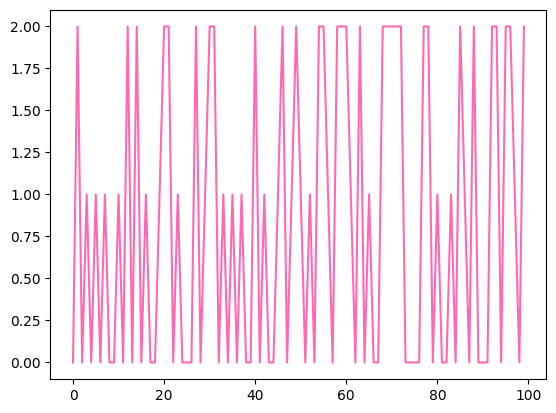

In [11]:
def get_trajectory(matrix, iterations = 100):
    trajectory = np.zeros(iterations)
    x = 0
    for i in range(1, iterations):
        x = random.choices([0,1,2], weights = matrix[x], k=1)[0]
        trajectory[i] = x
    return trajectory

def model_traj(matrix, n = 1000, iterations = 10000):
    stationary = find_erg(matrix)
    values = []
    for _ in range(n):
        traj = get_trajectory(matrix, iterations)
        emp = [np.sum(traj==i)/iterations for i in [0,1,2]]
        values.append((emp[0]-stationary[0])*np.sqrt(iterations))

    plt.hist(values, density = True, color='blue', bins = 15)



matrix = np.array([[1/3,1/3,1/3],
                   [3/4,0,1/4],
                   [1/2, 1/6, 1/3]])

iterations = 100

stationary = find_erg(matrix)
traj = get_trajectory(matrix, iterations)
emp = [np.sum(traj==i)/iterations for i in [0,1,2]]
plt.plot(traj, color='hotpink')
print(stationary)
print(emp)



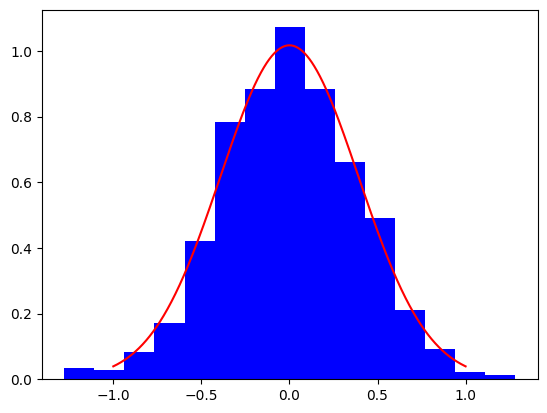

In [13]:
model_traj(matrix, n = 1000, iterations=10000)

s = stationary[0]
x = np.linspace(-1,1,1000)

scale2 = s*(1-s) + 2*np.sum([s*(np.linalg.matrix_power(matrix, n = k)[0,0] - s) for k in range(1, 50)])

plt.plot(x, stats.norm.pdf(x, scale = np.sqrt(scale2)), color = 'red')
plt.show()

3. В файле MarkovChain.txt находится м.в.п. цепи, не имеющей несущественных состояний. Написать программу, которая а) разделит состояния на неразложимые классы, б)* каждый из классов на подклассы состояний в соответствии с периодичностью цепи.

In [44]:
matrix = np.loadtxt('MarkovChain.txt', delimiter=';')


def find_reachable_states(transition_matrix, start_state):
    n = transition_matrix.shape[0]
    reachable = set([start_state])
    new_states = set([start_state])
    
    while new_states:
        next_states = set()
        for state in new_states:
            for next_state in range(n):
                if transition_matrix[state, next_state] > 0 and next_state not in reachable:
                    next_states.add(next_state)
        reachable.update(next_states)
        new_states = next_states
    
    return reachable


def find_classes(transition_matrix):
    # 
    n = transition_matrix.shape[0]
    classes = [] # massive of sets
    non_sorted_states = set(range(n)) # states that are already sorted
    while non_sorted_states:
        start_state = non_sorted_states.pop()
        new_class = find_reachable_states(transition_matrix, start_state)
        classes.append(new_class)
        non_sorted_states = non_sorted_states - new_class

    return classes

In [52]:
def find_period(transition_matrix): 
    n = transition_matrix.shape[0]
    state = 0
    for i in range(n):
        if transition_matrix[i,i] > 1e-10:
            return 1
    matrix_n = transition_matrix
    powers = []
    for i in range(n*2):
        if matrix_n[state, state] > 1e-10:
            powers.append(i+1)
        matrix_n = matrix_n @ transition_matrix
    return gcd(*powers)


def find_period_classes(transition_matrix , state_class):
    # cut the minor for the class
    n = len(state_class)
    state_list = sorted(list(state_class)) # old state indexing
    old_to_new = {old : new for new, old in enumerate(state_list)}
    transition_matrix = transition_matrix[np.ix_(state_list, state_list)]
    
    # find the period and prepare d classes
    period = find_period(transition_matrix)
    if period == 1:
        return [set(state_list)]

    period_classes = [set() for _ in range(period)]
    
    non_reached_states = set(range(1, n))
    start_state = 0
    period_classes[0].add(start_state)

    current_class = 0
    while non_reached_states:
        next_class = (current_class + 1) % period
        new_states_found = False
        # не оптимально 
        for current_state in list(period_classes[current_class]):
            for next_state in range(n):
                if transition_matrix[current_state, next_state] > 0 and next_state in non_reached_states:
                    new_states_found= True
                    period_classes[next_class].add(next_state)
                    non_reached_states.remove(next_state)
        current_class = next_class

        if not new_states_found and non_reached_states:
            print("ERROR couldn't find new states, but not all states reached")
            #break


    # возвращаем индексацию
    period_classes_old = []

    for period in period_classes:
        period_old = set()
        for state in period:
            period_old.add(state_list[state])
        period_classes_old.append(period_old)


    return period_classes_old
        



In [54]:
matrix = np.array([[0, 0, 1, 0],
                    [0, 0, 0, 1],
                    [1, 0, 0, 0],
                    [0, 1, 0, 0]])

matrix = np.loadtxt('MarkovChain.txt', delimiter=';')
classes = find_classes(matrix)
n = len(classes)

print(f"Number of classes = {n}")
print(classes)

for state_class in classes:
    print("")
    print(state_class)
    print("\nPeriod classes: ")
    period_classes = find_period_classes(matrix, state_class)
    for period_class in period_classes:
        print(period_class)

    print("\n======================================================\n")


Number of classes = 6
[{0, 37}, {1, 2, 5, 7, 9, 10, 11, 12, 13, 14, 15, 19, 20, 21, 25, 26, 27, 28, 29, 30, 32, 33, 34, 35, 42, 43, 44, 47, 49}, {48, 17, 3}, {16, 18, 4, 22, 41, 46}, {36, 23, 38, 6, 8, 24, 40, 45}, {39, 31}]

{0, 37}

Period classes: 
{0}
{37}



{1, 2, 5, 7, 9, 10, 11, 12, 13, 14, 15, 19, 20, 21, 25, 26, 27, 28, 29, 30, 32, 33, 34, 35, 42, 43, 44, 47, 49}

Period classes: 
{1, 14, 26, 28, 30}
{5, 9, 11, 43, 20, 25}
{32, 33, 2, 34, 7, 42, 13, 19, 27}
{35, 10, 12, 44, 15, 47, 49, 21, 29}



{48, 17, 3}

Period classes: 
{3}
{17}
{48}



{16, 18, 4, 22, 41, 46}

Period classes: 
{4}
{16, 46}
{41, 18, 22}



{36, 23, 38, 6, 8, 24, 40, 45}

Period classes: 
{8, 38, 6, 23}
{24, 40, 36, 45}



{39, 31}

Period classes: 
{31}
{39}




4. Пусть ξn – ЦМ с м.в.п.


0 0 1/2 1/2

0 0 0 1

1/2 0 0 1/2

1/3 1/3 1/3 0


Какую м.в.п. имеет обращенная цепь ξ_N−n? Исследовать к какому распределению сходится а) прямая цепь б) обращенная цепь?

In [8]:
# p_i,j ' = p_i,j*p_j/p_i
# find erg

matrix = np.array([[0,0,1/2,1/2],
                   [0,0,0,1],
                   [1/2,0,0,1/2],
                   [1/3,1/3,1/3,0]])

p = find_erg(matrix)
print("Эргодическое распределение исходной цепи")
print(p)
print("")

matrix_reverse = matrix.T*p/p[:, np.newaxis]
p_reverse = find_erg(matrix_reverse)
print("Переходная матрица обращенной цепи")
print(matrix_reverse)

print("")
print("Эргодическое распределение обращенной цепи")
print(p_reverse)


Эргодическое распределение исходной цепи
[0.25  0.125 0.25  0.375]

Переходная матрица обращенной цепи
[[0.         0.         0.5        0.5       ]
 [0.         0.         0.         1.        ]
 [0.5        0.         0.         0.5       ]
 [0.33333333 0.33333333 0.33333333 0.        ]]

Эргодическое распределение обращенной цепи
[0.25  0.125 0.25  0.375]


5. Моделировать случайное блуждание а) на целочисленной решетке прямой, выбирающее равновероятно
одну из двух соседних точек б) на целочисленной решетке плоскости, выбирающее равновероятно одну
из четырех соседних точек в) в трехмерном пространстве, выбирающее равновероятно одну из шести
соседних точек. Какие из них, исходя из моделирования, оказались возвратными?

In [2]:
def sim_rw_dim(x_gen, num_steps, dim):
    x0 = np.zeros(dim)
    num_return = 0
    x = [x0]
    for _ in range(num_steps):
        x0 += x_gen()
        x.append(x0)
        if not np.any(x0):
            return 1
    return 0

def r1():
    return np.random.choice([-1,1], size = 1)[0]

def r2():
    steps = [np.array([-1, 0]), np.array([1, 0]), np.array([0, -1]), np.array([0, 1])]
    i = np.random.choice(4, size = 1)[0]
    return steps[i]

def r3():
    steps = [np.array([-1, 0, 0]), np.array([1, 0, 0]), np.array([0, -1, 0]), np.array([0, 1, 0]), np.array([0,0,1]), np.array([0,0,-1])]
    i = np.random.choice(6, size = 1)[0]
    return steps[i]


def check_return(x_gen, dim, num_vals = [10, 50, 100]):
    mass = []
    num_t = 100
    for num_s in num_vals:
        num_return = 0
        for _ in range(num_t):
            num_return += sim_rw_dim(x_gen, num_steps= num_s, dim = dim)
        mass.append(num_return/num_t)

    plt.plot(num_vals, mass, marker='o', label=f'dim = {dim}')
    



In [28]:
a = np.zeros(2)
b = np.array([0,1])
not np.any(b)

False

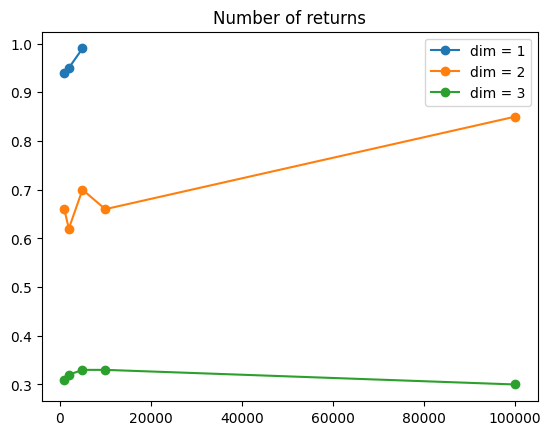

In [8]:
num_vals1 = [1000, 2000, 5000]
num_vals2 = [1000, 2000, 5000, 10000, 100000]
num_vals3 = [1000, 2000, 5000, 10000, 100000]

check_return(r1,1, num_vals1)
check_return(r2,2, num_vals2)
check_return(r3, 3, num_vals3)
plt.legend()
plt.title('Number of returns')
plt.show()


6* (Засчитывается также как факультатив по теме 3 теории случайных процессов). Сгенерировать
урну Эренфестов: в урне лежит N белых и N черных шаров, вытаскиваются по одному шару наугад,
перекрашиваются в противоположный цвет и возвращаются. Пусть Xn – число белых шаров в урне в
момент n. Рассмотреть N = 5 и N = 50.

• Оценить с помощью ОМП (не используя информацию о структуре цепи) матрицу вероятностей
перехода. Хорошо ли оценились параметры?

• Оценить дисперсию стационарного распределения с помощью ЗБЧ для марковской цепи.

In [3]:
def model_eren(N, n):
    # white = 0
    # black = 1
    x = np.zeros(n+1)
    x[0] = N
    for i in range(1, n+1):
        ball = np.random.choice([0]*int(x[i-1]) + [1]*(2*N - int(x[i-1])))
        if ball == 1:
            x[i] = x[i-1] + 1
        else:
            x[i] = x[i-1] - 1
    return x


def mle_markov_chain(x, N):
    num_exit = np.zeros(2*N+1)
    mle_matrix = np.zeros((2*N+ 1, 2*N+1))
    for i in range(len(x) - 1):
        mle_matrix[int(x[i])][int(x[i+1])] += 1
        num_exit[int(x[i])] += 1
    for i in range(2*N+1):
        if num_exit[i] > 0:
            mle_matrix[i] /= num_exit[i]
    return mle_matrix


def transition_matrix(N):
    matrix = np.zeros((2*N+1, 2*N+1))
    matrix[0, 1] = 1
    matrix[-1, -2] = 1
    for i in range(1, 2*N):
        matrix[i, i-1] = i/(2*N)
        matrix[i, i+1] = (2*N-i)/(2*N)
    return matrix



In [2]:
def compare_matricies(N, n):
    true_matrix = transition_matrix(N)
    x = model_eren(N, n)
    mle_matrix = mle_markov_chain(x, N)
    mse = np.mean((mle_matrix - true_matrix)**2) # mean square error
    print((true_matrix - mle_matrix)[:3, :3])
    print(f"Mean square error for matricies = {mse}")

    est_var = np.var(x)
    true_var = N/2
    print(f'Estimate variance = {est_var}, true variance = {true_var}, diff = {np.abs(est_var - true_var)}')


In [16]:
N = 5
n = 1000
compare_matricies(N, n)

[[ 0.          0.          0.        ]
 [-0.025       0.          0.025     ]
 [ 0.         -0.01538462  0.        ]]
Mean square error for matricies = 0.008588193082738173
Estimate variance = 2.858895350403842, true variance = 2.5, diff = 0.3588953504038419


In [6]:
N = 50
n = 100000
compare_matricies(N, n)

[[0.   1.   0.  ]
 [0.01 0.   0.99]
 [0.   0.02 0.  ]]
Mean square error for matricies = 0.004505628330081238
Estimate variance = 25.494394716356233, true variance = 25.0, diff = 0.4943947163562328
